## 記述統計

In [ ]:
import numpy as np
import pandas as pd

x = [165, 170, 175, 180, 185]
np.mean(x) # リストの場合

x = np.array( # アレイ
    [165, 170, 175, 180, 185])
x.mean() # np.mean(x)も可

x = pd.Series( # シリーズ
    [165, 170, 175, 180, 185])
x.mean() # np.mean(x)も可

175.0

In [ ]:
n = len(x) # サンプルサイズ
sum(x) / n

175.0

In [ ]:
y = [173, 174, 175, 176, 177]
np.mean(y)

175.0

In [ ]:
np.var(x, ddof=1) # xの分散

np.var(y, ddof=1) # yの分散

2.5

In [ ]:
sum((x - np.mean(x))**2) / (n - 1)

62.5

In [ ]:
np.std(x, ddof=1) # xの標準偏差

np.std(y, ddof=1) # yの標準偏差

1.5811388300841898

In [ ]:
np.var(x, ddof=1)**0.5 # xの標準偏差

7.905694150420948

In [ ]:
s = pd.Series(x)
s.describe() # 統計量の計算

count      5.000000
mean     175.000000
std        7.905694
min      165.000000
25%      170.000000
50%      175.000000
75%      180.000000
max      185.000000
dtype: float64

In [ ]:
x = [165, 170, 175, 180, 185]

print(np.var(x, ddof=1)) # 不偏分散

print(np.var(x, ddof=0)) # 標本分散

62.5
50.0


In [ ]:
print(np.std(x, ddof=1)) # √不偏分散

print(np.std(x, ddof=0)) # √標本分散

7.905694150420948
7.0710678118654755


In [ ]:
np.std(x, ddof=1) / len(x)**0.5

3.5355339059327373

In [ ]:
import numpy as np
import pandas as pd

my_df = pd.DataFrame({
    'name':    ['A', 'B', 'C', 'D'],
    'english': [ 60,  90,  70,  90],
    'math':    [ 70,  80,  90, 100],
    'gender':  ['f', 'm', 'm', 'f']})

In [ ]:
my_df['english'].var(ddof=1)
# あるいは
np.var(my_df['english'], ddof=1)


225.0

In [ ]:
my_df.iloc[:, [1, 2]].apply(
    lambda x: np.var(x, ddof=1))


english    225.000000
math       166.666667
dtype: float64

In [ ]:
my_df.describe()

,english,math
count,4.0,4.000000
mean,77.5,85.000000
std,15.0,12.909944
min,60.0,70.000000
25%,67.5,77.500000
50%,80.0,85.000000
75%,90.0,92.500000
max,90.0,100.000000


## データの可視化

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
iris = sm.datasets.get_rdataset('iris', 'datasets').data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


array([[<Axes: title={'center': 'Sepal.Length'}>]], dtype=object)

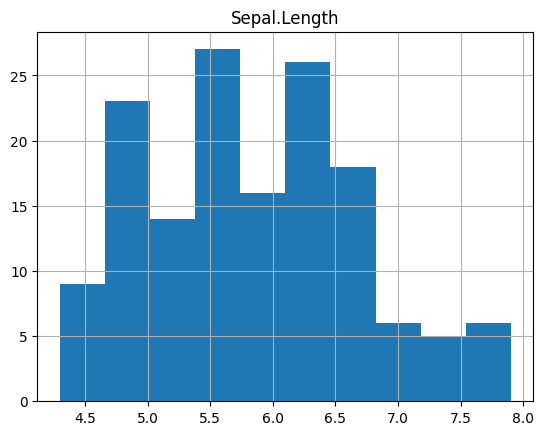

In [ ]:
iris.hist('Sepal.Length')

array([[<Axes: title={'center': 'Sepal.Length'}>]], dtype=object)

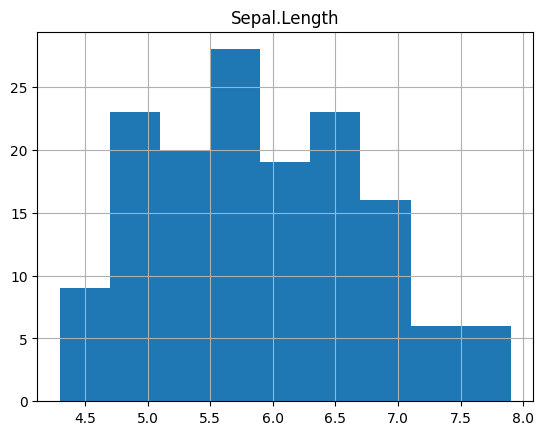

In [ ]:
x = iris['Sepal.Length']
tmp = np.linspace(min(x), max(x), 10)
iris.hist('Sepal.Length',
          bins=tmp.round(2))

<Axes: xlabel='Sepal.Length', ylabel='Sepal.Width'>

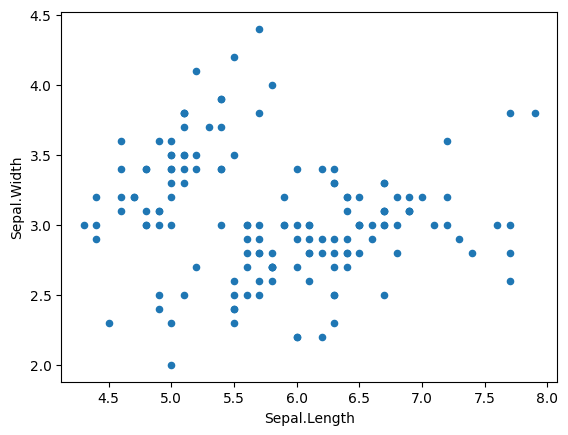

In [ ]:
iris.plot('Sepal.Length',
          'Sepal.Width',
          kind='scatter')

<Axes: >

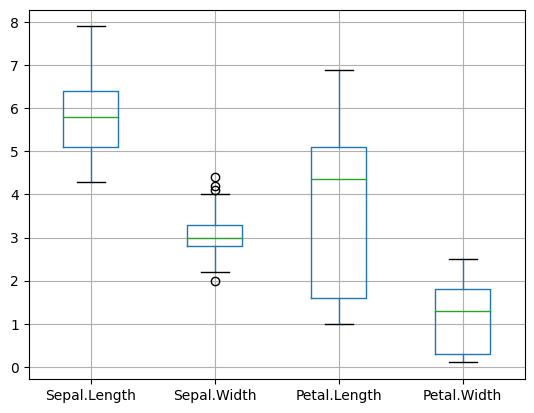

In [ ]:
iris.boxplot()

In [ ]:
pd.options.display.float_format = (
    '{:.2f}'.format)
my_df = (iris.describe().transpose()
    [['mean', 'std']])
my_df['se'] = (my_df['std'] /
               len(iris)**0.5)
my_df

,mean,std,se
Sepal.Length,5.84,0.83,0.07
Sepal.Width,3.06,0.44,0.04
Petal.Length,3.76,1.77,0.14
Petal.Width,1.20,0.76,0.06


<Axes: >

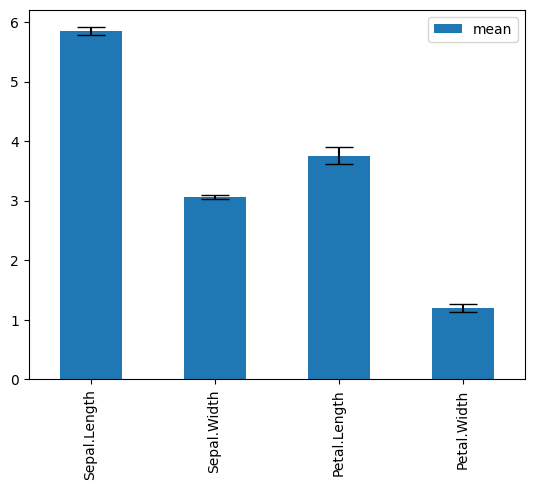

In [ ]:
my_df.plot(y='mean', kind='bar', yerr='se', capsize=10)

In [ ]:
my_group = iris.groupby('Species')                    # 品種ごとに，
my_df = my_group.agg('mean')                          # 各変数の，平均と
my_se = my_group.agg(lambda x: x.std() / len(x)**0.5) # 標準誤差を求める．
my_se

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,0.05,0.05,0.02,0.01
versicolor,0.07,0.04,0.07,0.03
virginica,0.09,0.05,0.08,0.04


<Axes: xlabel='Species'>

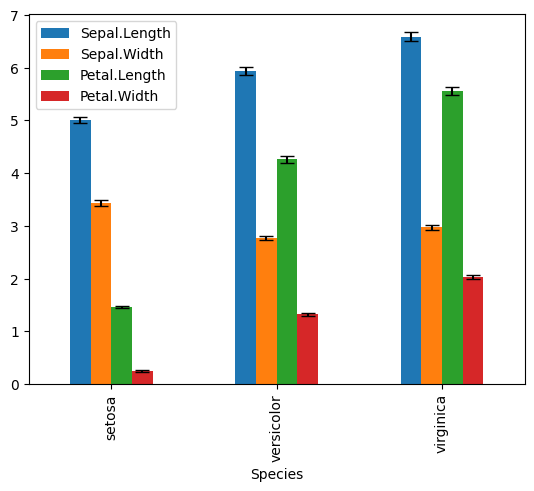

In [ ]:
my_group.agg('mean').plot(kind='bar', yerr=my_se, capsize=5)